# MWE: a Gaussian-process prior on the image

The other imaging MWEs regularise the pixels with a penalty, such as maximum entropy or total squared variation, at a weight chosen from an L-curve. A Gaussian-process prior is an alternative. The log-brightness of the image is modelled as a smooth random field about a template, with a standard deviation σ and a correlation length ℓ, and the fit maximises the posterior.

`drpangloss.fields.GaussianField` writes this field in whitened form. The image's cosine (DCT) coefficients are independent standard normals, scaled by a Matérn-like spectrum. The prior then becomes plain least-squares residuals, so Levenberg–Marquardt can fit it, and the same parameterisation suits sampling.

This notebook images the two-night VLTI scene of the long-baseline MWE: a star with a ring and a blob whose flux relative to the star follows a power law. It uses a GP envelope, fits the SPARCO spectrum along with it, and compares the result with maximum entropy. You should come away knowing how to set up a GP image, what σ and ℓ do, and how its MAP compares with a classical regulariser.

W1001 17:57:23.276480 10944664 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


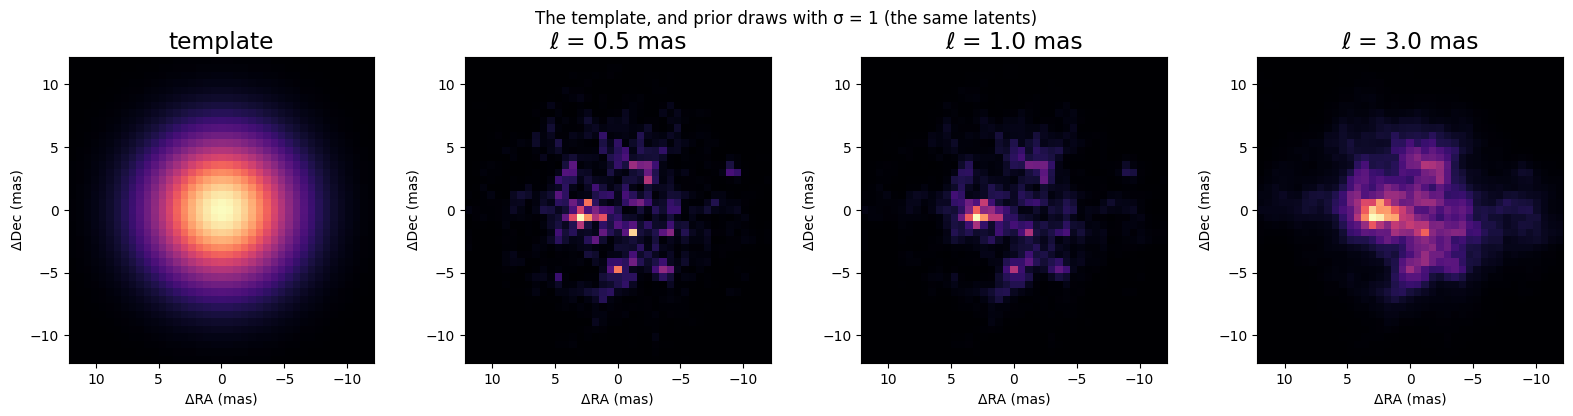

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist
from tqdm.auto import tqdm

from drpangloss.coverage import vlti_oidata
from drpangloss.fields import GaussianField
from drpangloss.fitting import fit
from drpangloss.imaging import MaxEntropy, beam, field_of_view, image_priors, l_curve, starting_image
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import gaussian_blob, ring
from drpangloss.spectra import PowerLaw

templates = [vlti_oidata(hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0)), vlti_oidata(hour_angles_h=(-2.25, -0.75, 0.75, 2.25))]
fov, npix = field_of_view(templates[0]), 40
scale = fov / npix
truth_image = 0.8 * ring(npix, scale, 6.0, 1.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.4, asymmetry_pa_deg=90.0) + 0.2 * gaussian_blob(npix, scale, 0.5, dra=-7.0, ddec=5.0)
truth_image = truth_image / truth_image.sum()
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=PowerLaw(0.5, 2.0, 3.5e-6)))
nights = [t.with_model(truth, key=jax.random.PRNGKey(k)) for k, t in enumerate(templates)]

# The image grid and support come from starting_image; the template is a centred Gaussian.
start = starting_image(nights, hole_mas=0.5 * beam(nights).minor_mas)
n, h = start.env.log_brightness.shape[0], start.env.pixel_scale_mas
template = onp.asarray(GaussianDisk(4.0).render(n, n * h))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_model(Image(GaussianField(onp.zeros((n, n)), mean=template), h), fov_mas=n * h, npix=n, ax=axes[0], title="template")
for ax, length in zip(axes[1:], (0.5, 1.0, 3.0)):
    latent = jax.random.normal(jax.random.PRNGKey(1), (n, n))
    draw = Image(GaussianField(latent, sigma=1.0, length_mas=length, mean=template), h)
    plot_model(draw, fov_mas=n * h, npix=n, ax=ax, title=f"ℓ = {length} mas")
fig.suptitle("The template, and prior draws with σ = 1 (the same latents)")
plt.tight_layout()
plt.show()

## MAP fits over σ and ℓ

The GP envelope keeps `starting_image`'s grid, its hole of half a beam under the star, and its flux. Its flux becomes a `PowerLaw` with free ratio and index. `image_priors` gives the field's latents standard-normal priors, and every term of the objective is then a least-squares residual, so `fit` uses Levenberg–Marquardt.

σ and ℓ are held fixed in each fit, since their MAP values are biased (`fit` warns if they are left free). Here a few pairs are tried, and the pair is chosen by the discrepancy principle, on the night whose χ² per point is closest to one. The next stage chooses them from the Bayesian evidence instead.

In [2]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


spectrum_priors = {"env.flux.ratio": dist.Uniform(0.0, 5.0), "env.flux.index": dist.Uniform(-6.0, 6.0)}
grid = [(length, sigma) for length in (1.0, 2.0) for sigma in (1.0, 2.0, 4.0, 8.0)]
gp = {}
for length, sigma in tqdm(grid, desc="σ, ℓ"):
    field = GaussianField(onp.zeros((n, n)), sigma, length, mean=template)
    scene = System(star=PointSource(), env=Image(field, h, support=start.env.support, flux=PowerLaw(float(start.env.flux), 0.0, 3.5e-6)))
    gp[length, sigma] = fit(scene, image_priors(scene) | spectrum_priors, nights)

print(f"{'ℓ (mas)':>7s} {'σ':>4s}  converged  steps  chi2/N by night  NCC")
for (length, sigma), r in gp.items():
    chi2 = [c / m for c, m in zip(r.info["chi2"], r.info["ndata"])]
    print(f"{length:7.1f} {sigma:4.1f}  {str(r.info['converged']):9s} {r.info['steps']:5d}  {chi2[0]:.3f}, {chi2[1]:.3f}     {ncc(r.model.env.render(npix, fov), truth_image):.3f}")
best = min(gp, key=lambda k: abs(max(c / m for c, m in zip(gp[k].info["chi2"], gp[k].info["ndata"])) - 1.0))
print(f"chosen by the discrepancy principle: ℓ = {best[0]} mas, σ = {best[1]}")

σ, ℓ:   0%|          | 0/8 [00:00<?, ?it/s]

ℓ (mas)    σ  converged  steps  chi2/N by night  NCC


    1.0  1.0  True         23  1.040, 0.997     0.933
    1.0  2.0  True         33  1.014, 0.983     0.933
    1.0  4.0  True         38  1.000, 0.973     0.928
    1.0  8.0  True         48  0.992, 0.969     0.885
    2.0  1.0  True         26  1.054, 1.010     0.902
    2.0  2.0  True         39  1.019, 0.983     0.919
    2.0  4.0  True         43  1.004, 0.975     0.929
    2.0  8.0  True         53  0.995, 0.971     0.916
chosen by the discrepancy principle: ℓ = 1.0 mas, σ = 4.0


## The maximum-entropy reference

For comparison, the same data are reconstructed as in the long-baseline MWE: a maximum-entropy L-curve over the weight, with the weight at the discrepancy point.

In [3]:
mem_start = start.set("env.flux", PowerLaw(start.env.flux, 0.0, 3.5e-6))
curve = l_curve(mem_start, image_priors(mem_start) | spectrum_priors, nights, MaxEntropy(1.0, path="env"), jnp.logspace(-1, 4, 11))
chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy() or curve.corner()))))
mem = curve.results[chosen]
for name, r in (("GP (MAP)", gp[best]), ("MEM", mem)):
    print(f"{name:8s}: flux ratio {float(r.values['env.flux.ratio']):.3f} (truth 0.5), index {float(r.values['env.flux.index']):.2f} (truth 2); NCC {ncc(r.model.env.render(npix, fov), truth_image):.3f}")

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:684: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


GP (MAP): flux ratio 0.511 (truth 0.5), index 1.91 (truth 2); NCC 0.928
MEM     : flux ratio 0.509 (truth 0.5), index 1.87 (truth 2); NCC 0.885


## GP against maximum entropy

The truth, the GP reconstruction at the chosen σ and ℓ, and the MEM reconstruction, each with its beam shaded. Below are their signed differences from the truth, both normalised to unit flux; these are MAP images, so the differences are not z-scores.

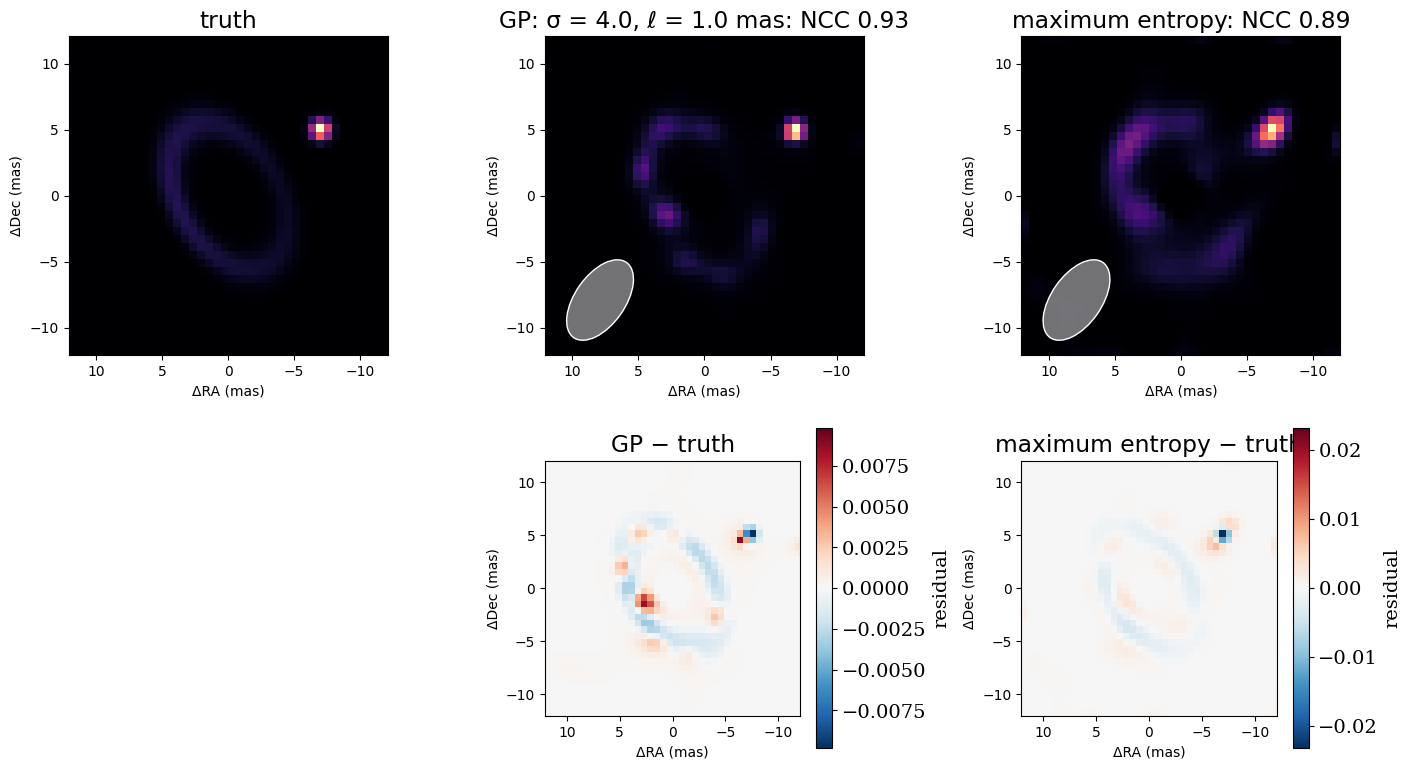

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (name, r) in enumerate([(f"GP: σ = {best[1]}, ℓ = {best[0]} mas", gp[best]), ("maximum entropy", mem)], start=1):
    image = r.model.env.render(npix, fov)
    plot_model(r.model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(image, truth_image):.2f}", beam=beam(nights))
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title=f"{name.split(':')[0]} − truth")
plt.tight_layout()
plt.show()

## Summary

A `GaussianField` makes the image a Gaussian process about a template. Under `image_priors`' standard-normal priors on its latents, the MAP is an ordinary least-squares fit:
- **Speed.** Levenberg–Marquardt converges in a few dozen steps and a few seconds, against thousands of L-BFGS steps for maximum entropy.
- **Fidelity.** On this scene the GP image matches or beats the maximum-entropy one, and it recovers the SPARCO spectrum as well. The result is not very sensitive to σ near the discrepancy choice.
- **Two hyperparameters instead of one weight.** σ and ℓ take the place of the regularisation weight. Choosing them from the evidence, and sampling them with the image, are the next steps.